In [140]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler,OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score
from sklearn.metrics import classification_report

In [141]:
df=pd.read_csv('loan_data.csv')
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [142]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

In [143]:
x=df.drop(columns='loan_status')
y=df['loan_status']

In [144]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [145]:
num_col=x.select_dtypes('number').columns
cat_col=x.select_dtypes('object').columns
cat_col

C:\Users\ayyok\AppData\Local\Temp\ipykernel_15692\757087237.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col=x.select_dtypes('object').columns


Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='str')

In [146]:
num_col

Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score'],
      dtype='str')

In [147]:
df[cat_col].nunique()

person_gender                     2
person_education                  5
person_home_ownership             4
loan_intent                       6
previous_loan_defaults_on_file    2
dtype: int64

In [148]:
x.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No


<Axes: >

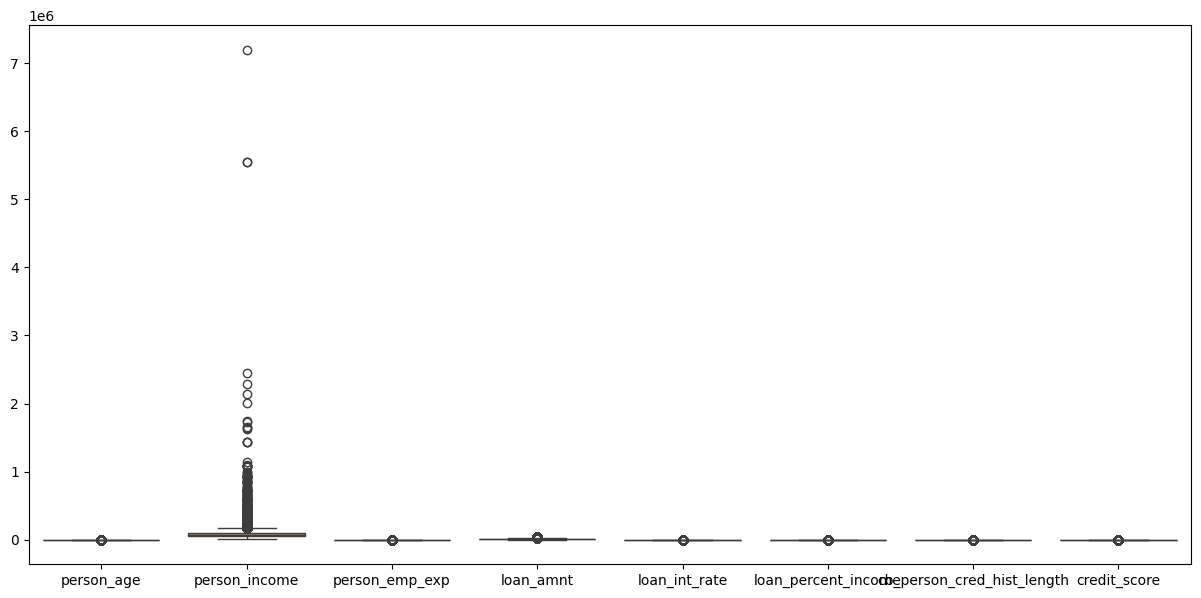

In [149]:
plt.figure(figsize=(15,7))
sns.boxplot(df[num_col])

In [150]:
preprocessing=ColumnTransformer(
    transformers=[
        ('robust_scaling',RobustScaler(),num_col),
        ('encodig',OneHotEncoder(handle_unknown='ignore'),['person_gender', 'person_home_ownership','loan_intent', 'previous_loan_defaults_on_file']),
        ("ordencode",OrdinalEncoder(categories=[["Master", "High School", "Bachelor", "Associate", "Doctorate"]]), ['person_education'])
    ]
)
preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('robust_scaling', ...), ('encodig', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` 

In [151]:
main_pipeline=Pipeline(
    steps=[
        ('pre',preprocessing),
        ('model',LogisticRegression())
    ]
)
main_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('robust_scaling', ...), ('encodig', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, defaul

In [152]:
main_pipeline.fit(xtrain,ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['person_age','person_gender','person_education',..., 'cb_person_cred_hist_length','credit_score', 'previous_loan_defaults_on_file']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('robust_scaling', ...), ('encodig', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped.

**Model Evaluation**

In [153]:
ytrain.value_counts()

loan_status
0    28010
1     7990
Name: count, dtype: int64

In [154]:
ytest.value_counts()

loan_status
0    6990
1    2010
Name: count, dtype: int64

In [155]:
ytrain_pred=main_pipeline.predict(xtrain)
print(classification_report(ytrain,ytrain_pred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93     28010
           1       0.78      0.75      0.76      7990

    accuracy                           0.90     36000
   macro avg       0.85      0.84      0.85     36000
weighted avg       0.90      0.90      0.90     36000



In [156]:
ytest_pred=main_pipeline.predict(xtest)
print(classification_report(ytest,ytest_pred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93      6990
           1       0.77      0.74      0.76      2010

    accuracy                           0.89      9000
   macro avg       0.85      0.84      0.84      9000
weighted avg       0.89      0.89      0.89      9000



**Confusion Metrix**

In [157]:
cm_train=confusion_matrix(ytrain,ytrain_pred)
cm_train

array([[26315,  1695],
       [ 2004,  5986]])

In [158]:
cm_test=confusion_matrix(ytest,ytest_pred)
cm_test

array([[6554,  436],
       [ 519, 1491]])

**Conclusion**

**Train data**

Out of all 7990 (1) labels 5988 labels are correctly predicted as (1).

Out of all 7990 (1) labels 2002 labels are wrongly predicted as (1).

Out of all 28010 (0) labels 26317 labels are correctly predicted as (0).

Out of all 28010 (0) labels 1693 labels are wrongly predicted as l(0).

**Test data**

Out of all 2010 (1) labels 1491 labels are correctly predicted as (1).

Out of all 2010 (1) labels 519 labels are wrongly predicted as (1).

Out of all 6990 (0) labels 6556 labels are correctly predicted as (0).

Out of all 6990 (0) labels 432 labels are wrongly predicted as (0).


**Precision Score**

**Precision score for loan aproved**

In [159]:
#Train data
precision_score(ytrain,ytrain_pred,pos_label=1)

0.7793256086447077

In [160]:
#Test data
precision_score(ytest,ytest_pred,pos_label=1)

0.7737415672029061

In [161]:
#Sum of predicted loan aproved labels
cm_train[:,1].sum()

np.int64(7681)

In [162]:
#Sum of predicted loan not aproved labels
cm_test[:,1].sum()

np.int64(1927)

**Conclusion**

**Train data**

Out of all 7681 (1) 77% labels are correctly predicted as (1).

Out of all 7661 (1) labels 33% labels are wrongly predicted as (0).

**Test data**

Out of all 1923 (1) labels 77% labels are correctly predicted as (1).

Out of all 1923 (1) labels 33% labels are wrongly predicted as (0).

**Precision score for loan not approved**

In [163]:
#Train data
precision_score(ytrain,ytrain_pred,pos_label=0)

0.9292347893640313

In [164]:
#Test data
precision_score(ytest,ytest_pred,pos_label=0)

0.9266223667467836

In [165]:
#Sum of predicted loan not aproved labels
cm_train[:,0].sum()

np.int64(28319)

In [166]:
#Sum of predicted loan not aproved labels
cm_test[:,0].sum()

np.int64(7073)

**Conclusion**

**Train data**

Out of all 28319 (0) labels 92% labels are correctly predicted as (0).

Out of all 28319 (0) labels 8% labels are wrongly predicted as (1).

**Test data**

Out of all 7077 (0) labels 92% labels are correctly predicted as (0).

Out of all 7077 (0) labels 8% labels are wrongly predicted as (1).




**Recall score**

**Recall score for loan aproved**

In [167]:
recall_score(ytrain,ytrain_pred,pos_label=1)

0.7491864831038798

In [168]:
recall_score(ytest,ytest_pred,pos_label=1)

0.7417910447761195

In [169]:
ytrain.value_counts()

loan_status
0    28010
1     7990
Name: count, dtype: int64

In [170]:
ytest.value_counts()

loan_status
0    6990
1    2010
Name: count, dtype: int64

**Conclusion**

**Train data**

Out of all 7990 actual (1) labels 74% labels are correctly predicted as (1).

Out of all 7990 actual (1) labels 36% labels are wrongly predicted as (0).

**Test data**

Out of all 2010 actual (1) labels 74% labels are correctly predicted as (1).

Out of all 2010 actual (1) labels 36% labels are wrongly predicted as (0).

**Recall score for loan not aproved**

In [171]:
recall_score(ytrain,ytrain_pred,pos_label=0)

0.9394858978936095

In [172]:
recall_score(ytest,ytest_pred,pos_label=0)

0.9376251788268956

**Conclusion**

**Train data**

Out of all 28010 actual (0) labels 93% labels are correctly predicted as (0).

Out of all 28010 actual (0) labels 7% labels are wrongly predicted as (1).

**Test data**

Out of all 6990 actual (0) labels 93% labels are correctly predicted as (0).

Out of all 6990 (0) labels 7% labels are wrongly predicted as (1).

In [173]:
df['loan_status'].value_counts()

loan_status
0    35000
1    10000
Name: count, dtype: int64

**f1 score**

**f1 score for loan aproved labels**

In [174]:
f1_score(ytrain,ytrain_pred)

0.7639589049837279

In [175]:
f1_score(ytest,ytest_pred)

0.7574295148590298